In [1]:
!pip install keras



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install tensorflow


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(2)

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping


In [4]:
from PIL import Image, ImageChops, ImageEnhance
import io

def convert_to_ela_image(path, quality):
    image = Image.open(path).convert('RGB')
    
    # Save compressed image to in-memory buffer
    buffer = io.BytesIO()
    image.save(buffer, 'JPEG', quality=quality)
    buffer.seek(0)
    
    # Load compressed image from buffer
    temp_image = Image.open(buffer)
    
    # Compute difference (ELA)
    ela_image = ImageChops.difference(image, temp_image)

    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1
    scale = 255.0 / max_diff
    
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
    
    return ela_image


In [5]:
def prepare_image(image_path):
    return np.array(convert_to_ela_image(image_path, 90).resize(image_size)) / 255.0

xx = []  # ELA processed images
yy = []  # Labels: 1 for real, 0 for fake

In [6]:
image_size = (128, 128)  # Define image size globally

In [7]:
import os
import random
import numpy as np
# ------------ Load REAL images (Au) ------------
real_path = 'E:\ROP_Project\CASIA2\Au'   # authentic images
for dirname, _, filenames in os.walk(real_path):
    for filename in filenames:
        if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
            full_path = os.path.join(dirname, filename)
            xx.append(prepare_image(full_path))
            yy.append(1)
            if len(yy) % 500 == 0:
                print(f'Processing {len(yy)} images (real)')

# ------------ Load FAKE images (Tp) ------------
fake_path = 'E:\ROP_Project\CASIA2\Tp'   # tampered images
for dirname, _, filenames in os.walk(fake_path):
    for filename in filenames:
        if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
            full_path = os.path.join(dirname, filename)
            xx.append(prepare_image(full_path))
            yy.append(0)
            if len(yy) % 500 == 0:
                print(f'Processing {len(yy)} images (fake)')

print("Total images loaded:", len(xx), len(yy))

# ------------ Shuffle (image-level) ------------
combined = list(zip(xx, yy))
random.shuffle(combined)
xx, yy = zip(*combined)
xx = np.array(xx)
yy = np.array(yy)

Processing 500 images (real)
Processing 1000 images (real)
Processing 1500 images (real)
Processing 2000 images (real)
Processing 2500 images (real)
Processing 3000 images (real)
Processing 3500 images (real)
Processing 4000 images (real)
Processing 4500 images (real)
Processing 5000 images (real)
Processing 5500 images (real)
Processing 6000 images (real)
Processing 6500 images (real)
Processing 7000 images (real)
Processing 7500 images (fake)
Processing 8000 images (fake)
Processing 8500 images (fake)
Processing 9000 images (fake)
Processing 9500 images (fake)
Total images loaded: 9501 9501


In [8]:
SEQ_LEN = 5

# Convert to numpy
xx = np.array(xx)
yy = np.array(yy)

# Separate by class
xx_real = xx[yy == 1]
xx_fake = xx[yy == 0]

def make_sequences(x_class, label, seq_len):
    n_seq = len(x_class) // seq_len
    x_class = x_class[:n_seq * seq_len]
    x_seq = x_class.reshape(n_seq, seq_len, 128, 128, 3)
    y_seq = np.full((n_seq,), label, dtype=int)
    return x_seq, y_seq

xx_real_seq, yy_real_seq = make_sequences(xx_real, 1, SEQ_LEN)
xx_fake_seq, yy_fake_seq = make_sequences(xx_fake, 0, SEQ_LEN)

xx_seq = np.concatenate([xx_real_seq, xx_fake_seq], axis=0)
yy_seq = np.concatenate([yy_real_seq, yy_fake_seq], axis=0)

# Shuffle sequences
idx = np.random.permutation(len(xx_seq))
xx_seq = xx_seq[idx]
yy_seq = yy_seq[idx]

yy_seq_cat = to_categorical(yy_seq, 2)

xx_train, xx_val, yy_train, yy_val = train_test_split(
    xx_seq, yy_seq_cat, test_size=0.2, random_state=5, stratify=yy_seq
)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (TimeDistributed, Conv2D, MaxPooling2D, 
                                     BatchNormalization, Dropout, Flatten, 
                                     LSTM, Dense)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


def build_cnn_lstm_model(seq_len=SEQ_LEN):
    model = Sequential()
    
    # TimeDistributed CNN backbone (similar to your current CNN)
    model.add(TimeDistributed(
        Conv2D(32, (3,3), activation='relu', padding='same'),
        input_shape=(seq_len, 128, 128, 3)
    ))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu', padding='same')))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(MaxPooling2D(pool_size=(2,2))))
    model.add(TimeDistributed(Dropout(0.25)))

    model.add(TimeDistributed(Conv2D(64, (3,3), activation='relu', padding='same')))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(Conv2D(64, (3,3), activation='relu', padding='same')))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(MaxPooling2D(pool_size=(2,2))))
    model.add(TimeDistributed(Dropout(0.3)))

    model.add(TimeDistributed(Conv2D(128, (3,3), activation='relu', padding='same')))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(Conv2D(128, (3,3), activation='relu', padding='same')))
    model.add(TimeDistributed(BatchNormalization()))
    model.add(TimeDistributed(MaxPooling2D(pool_size=(2,2))))
    model.add(TimeDistributed(Dropout(0.4)))

    model.add(TimeDistributed(Flatten()))

    # LSTM over frame features
    model.add(LSTM(128, return_sequences=False))
    model.add(Dropout(0.5))

    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(2, activation='softmax'))

    return model

model = build_cnn_lstm_model()
model.summary()

init_lr = 1e-4
optimizer = Adam(learning_rate=init_lr)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=7,
                               restore_best_weights=True, verbose=1)
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=4,
                                 factor=0.5, min_lr=1e-6, verbose=1)

hist = model.fit(
    xx_train, yy_train,
    epochs=40,
    batch_size=8,          # smaller batch; sequences are heavier
    validation_data=(xx_val, yy_val),
    callbacks=[early_stopping, lr_reduction]
)

model.save('ela_cnn_lstm_casia2.h5')


e:\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 5, 128, 128,    │           896 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 128, 128,    │           128 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 128, 128,    │         9,248 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 5, 128, 128,    │           128 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 5, 64, 64, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 5, 64, 64, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 5, 64, 64, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 5, 64, 64, 64)  │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 5, 64, 64, 64)  │        36,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 5, 64, 64, 64)  │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 5, 32, 32, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 5, 32, 32, 64)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ (None, 5, 32, 32, 128) │        73,856 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ (None, 5, 32, 32, 128) │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_14             │ (None, 5, 32, 32, 128) │       147,584 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_15             │ (None, 5, 32, 32, 128) │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_16             │ (None, 5, 16, 16, 128) │             

 Total params: 17,165,602 (65.48 MB)

 Trainable params: 17,164,706 (65.48 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 611s 3s/step - accuracy: 0.8078 - loss: 0.4349 - val_accuracy: 0.8684 - val_loss: 0.4229 - learning_rate: 1.0000e-04
Epoch 2/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 557s 3s/step - accuracy: 0.9296 - loss: 0.2324 - val_accuracy: 0.8158 - val_loss: 0.4010 - learning_rate: 1.0000e-04
Epoch 3/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 557s 3s/step - accuracy: 0.9612 - loss: 0.1474 - val_accuracy: 0.6684 - val_loss: 0.6362 - learning_rate: 1.0000e-04
Epoch 4/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 570s 3s/step - accuracy: 0.9710 - loss: 0.1111 - val_accuracy: 0.9605 - val_loss: 0.1148 - learning_rate: 1.0000e-04
Epoch 5/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 560s 3s/step - accuracy: 0.9783 - loss: 0.0776 - val_accuracy: 0.9816 - val_loss: 0.0548 - learning_rate: 1.0000e-04
Epoch 6/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 559s 3s/step - accuracy: 0.9835 - loss: 0.0659 - val_accuracy: 0.7395 - val_loss: 0.6009 - learning_rate: 1.0000e-04
Epoch 7/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 566s 3s/step - acc

12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step 
Validation Accuracy (sequence-level): 98.16%
              precision    recall  f1-score   support

        Fake       0.96      0.95      0.96        82
        Real       0.99      0.99      0.99       298

    accuracy                           0.98       380
   macro avg       0.97      0.97      0.97       380
weighted avg       0.98      0.98      0.98       380



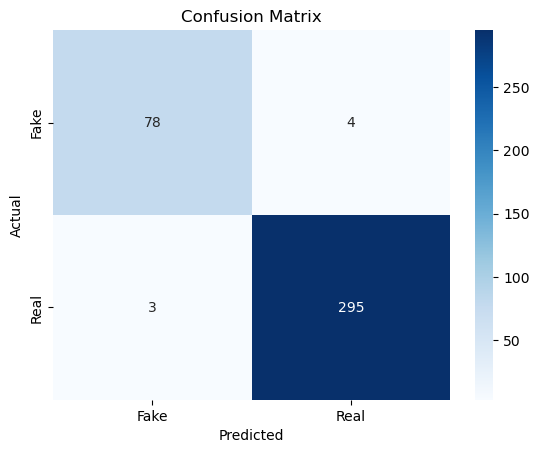

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

val_preds = model.predict(xx_val)
val_pred_labels = np.argmax(val_preds, axis=1)
val_true_labels = np.argmax(yy_val, axis=1)

val_acc = accuracy_score(val_true_labels, val_pred_labels)
print(f"Validation Accuracy (sequence-level): {val_acc*100:.2f}%")

print(classification_report(val_true_labels, val_pred_labels, target_names=['Fake', 'Real']))
cm = confusion_matrix(val_true_labels, val_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix'); plt.show()


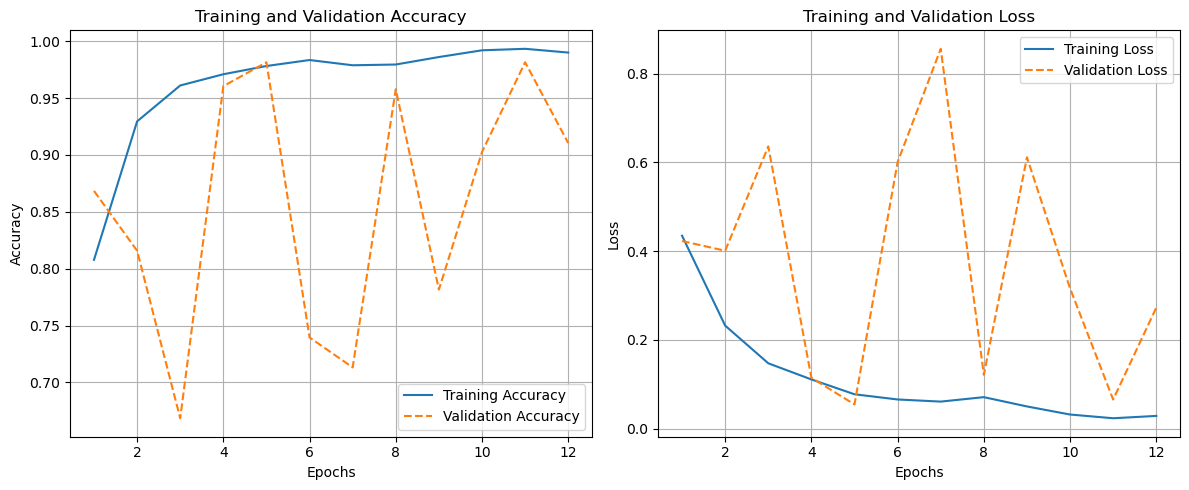

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step


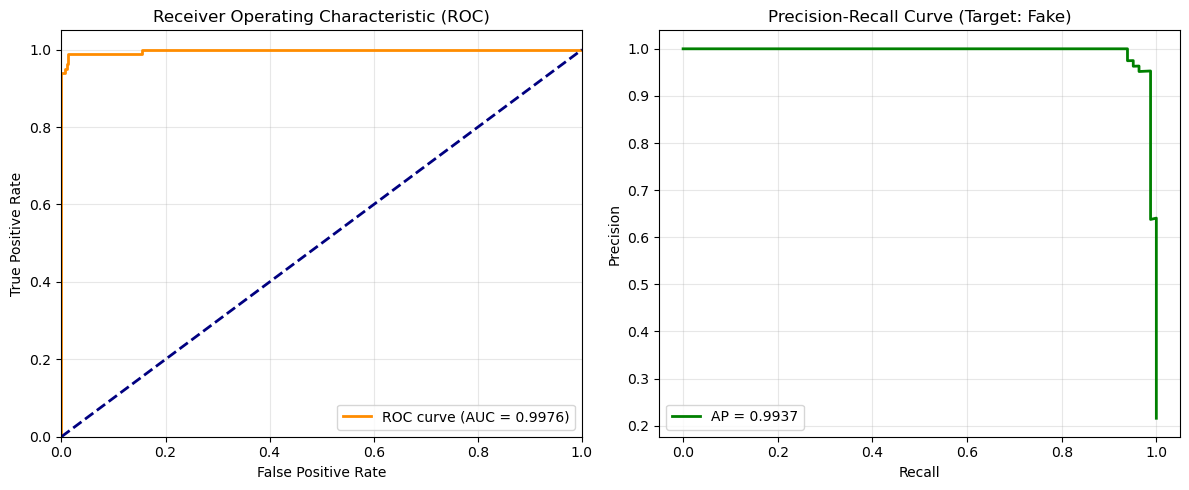

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ==========================================
# 1. Plot Training & Validation History
# ==========================================
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Call the function with your 'hist' object
plot_training_history(hist)

# ==========================================
# 2. Plot ROC Curve and Precision-Recall Curve
# ==========================================
# Get probabilities for the "Fake" class (Class 0)
# Note: In your code, Fake is label 0, Real is label 1.
# We predict probabilities for both. We focus on detecting 'Fake'.
y_pred_probs = model.predict(xx_val)
fake_probs = y_pred_probs[:, 0]  # Probability of being Fake (Class 0)
real_probs = y_pred_probs[:, 1]  # Probability of being Real (Class 1)

# Ground truth for 'Fake' class (1 if Fake, 0 if Real)
# Since your labels are one-hot, yy_val[:, 0] corresponds to the Fake column
y_true_fake = yy_val[:, 0] 

plt.figure(figsize=(12, 5))

# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_true_fake, fake_probs)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_true_fake, fake_probs)
avg_precision = average_precision_score(y_true_fake, fake_probs)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='green', lw=2, label=f'AP = {avg_precision:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Target: Fake)')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

OLDER CODE

In [11]:
# Load real images
import os
import random
from PIL import Image, ImageChops, ImageEnhance

real_path = 'E:\ROP_Project\CASIA2\Au'  # Replace with your real images folder path
for dirname, _, filenames in os.walk(real_path):
    for filename in filenames:
        if filename.lower().endswith(('.jpg', '.png')):
            full_path = os.path.join(dirname, filename)
            xx.append(prepare_image(full_path))
            yy.append(1)
            if len(yy) % 500 == 0:
                print(f'Processing {len(yy)} images (real)')

# Shuffle and limit
combined = list(zip(xx, yy))
random.shuffle(combined)
xx, yy = zip(*combined)
xx = list(xx)[:2100]
yy = list(yy)[:2100]
print(len(xx), len(yy))

AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [ ]:
# Load fake images
fake_path = 'E:\ROP_Project\CASIA2\Tp'  # Replace with your fake images folder path
for dirname, _, filenames in os.walk(fake_path):
    for filename in filenames:
        if filename.lower().endswith(('.jpg', '.png')):
            full_path = os.path.join(dirname, filename)
            xx.append(prepare_image(full_path))
            yy.append(0)
            if len(yy) % 500 == 0:
                print(f'Processing {len(yy)} images (fake)')

print(len(xx), len(yy))

xx = np.array(xx)
yy = to_categorical(yy, 2)

xx_train, xx_val, yy_train, yy_val = train_test_split(xx, yy, test_size=0.2, random_state=5)
print(len(xx_train), len(yy_train))
print(len(xx_val), len(yy_val))

Processing 2500 images (fake)
Processing 3000 images (fake)
Processing 3500 images (fake)
Processing 4000 images (fake)
4164 4164
3331 3331
833 833


In [ ]:
from keras.layers import BatchNormalization
from keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Enhanced data augmentation
datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
datagen.fit(xx_train)

def build_model():
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.25))
    
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.3))
    
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.4))
    
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(2, activation='softmax'))
    return model

model = build_model()
model.summary()

epochs = 30
batch_size = 32
init_lr = 1e-4

optimizer = Adam(learning_rate=init_lr)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
lr_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience=3, factor=0.5, min_lr=1e-6, verbose=1)

hist = model.fit(datagen.flow(xx_train, yy_train, batch_size=batch_size),
                 epochs=epochs,
                 validation_data=(xx_val, yy_val),
                 callbacks=[early_stopping, lr_reduction])

model.save('model_run1_enhanced.h5')

# Evaluate accuracies
train_preds = model.predict(xx_train)
train_preds_labels = np.argmax(train_preds, axis=1)
yy_train_labels = np.argmax(yy_train, axis=1)
train_acc = accuracy_score(yy_train_labels, train_preds_labels)
print(f"Training Accuracy: {train_acc * 100:.2f}%")

val_preds = model.predict(xx_val)
val_preds_labels = np.argmax(val_preds, axis=1)
yy_val_labels = np.argmax(yy_val, axis=1)
val_acc = accuracy_score(yy_val_labels, val_preds_labels)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

ValueError: Input to `.fit()` should have rank 4. Got array with shape: (1520, 5, 128, 128, 3)

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step
              precision    recall  f1-score   support

        Fake       0.86      0.94      0.90       407
        Real       0.94      0.85      0.89       426

    accuracy                           0.89       833
   macro avg       0.90      0.90      0.89       833
weighted avg       0.90      0.89      0.89       833



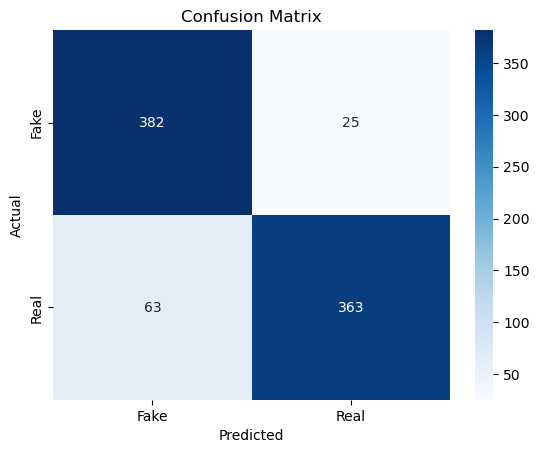

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict on validation images
val_preds = model.predict(xx_val)
val_pred_labels = np.argmax(val_preds, axis=1)
val_true_labels = np.argmax(yy_val, axis=1)

# Print classification report
print(classification_report(val_true_labels, val_pred_labels, target_names=['Fake', 'Real']))

# Confusion Matrix
cm = confusion_matrix(val_true_labels, val_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
new_image_path = 'E:/ROP_Project/CASIA2/Tp/Tp_D_CNN_M_N_nat00077_nat00077_10574.'
  

img = prepare_image(new_image_path)
img = img.reshape(1, 128, 128, 3)  
pred = model.predict(img)
class_index = np.argmax(pred)
classes = ['Fake', 'Real']
print(f'Prediction: {classes[class_index]}, Confidence: {pred[0][class_index]*100:.2f}%')


FileNotFoundError: [Errno 2] No such file or directory: 'E:/ROP_Project/CASIA2/Tp/Tp_D_CNN_M_N_nat00077_nat00077_10574.'